In [1]:
# This stuff only actually gets used in this cell:

from matplotlib import pyplot as plt

# Use the style file defined in the repository route
plt.style.use('../../paper.mplstyle')

# This is the folder where results plots will be saved:
paper_plots_dir = '../../paper/images/zerolatency_results'

# The common and plotting utils modules are in the parent
# `search` directory
# Here we add the `search` directory to the python path so we can
# do a local import

import sys
import os

parent_dir = os.path.abspath("..")

if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)


import common_utils
import plotting_utils
# import importlib
import copy
import numpy as np

# Get the truth times
import ldc.io.hdf5 as hdfio

/home/gareth.cabourndavies/environments/env_lisa_premerger_sangria/lib/python3.11/site-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal


In [2]:

# Set up some values to control things

data_file = '../../datasets/LDC2_sangria_hm_training.hdf'
delta_t = 5
sample_rate = 1 / delta_t

In [3]:
mbhb_sky, _ = hdfio.load_array(data_file, name="sky/mbhb/cat")

truth_times_s = mbhb_sky['CoalescenceTime']

In [4]:
mbhb_data = common_utils.load_ldc_timeseries(
    data_file,
    data_group='sky/mbhb/tdi',
    delta_t=delta_t,
)
del mbhb_data['LISA_T']

In [5]:
data = common_utils.load_ldc_timeseries(
    data_file,
    delta_t=delta_t
)
del data['LISA_T']

In [6]:
generated = copy.deepcopy(data)
for ts in generated.values():
    ts._data = np.zeros(len(ts), dtype=np.float64)

wfs = {}
for signal_number, mbhb in enumerate(mbhb_sky):
    print(f'Generating signal {signal_number} & Adding to timeseries')
    wf = common_utils.generate_waveform_for_data(
        mbhb,
        0,
        365 * 86400,
        delta_t,
    )
    wfs[signal_number] = wf
    # print('Adding to timeseries')
    for channel in generated.keys():
        generated[channel] += wf[channel]

print('Subtracting from data')
data_residual = {
    channel: data[channel] - generated[channel]
    for channel in data.keys()
}
print('Subtracting from MBHB-only dataset')
mbhb_residual = {
    channel: mbhb_data[channel] - generated[channel]
    for channel in data.keys()
}

Generating signal 0 & Adding to timeseries
Generating signal 1 & Adding to timeseries
Generating signal 2 & Adding to timeseries
Generating signal 3 & Adding to timeseries
Generating signal 4 & Adding to timeseries
Generating signal 5 & Adding to timeseries
Generating signal 6 & Adding to timeseries
Generating signal 7 & Adding to timeseries
Generating signal 8 & Adding to timeseries
Generating signal 9 & Adding to timeseries
Generating signal 10 & Adding to timeseries
Generating signal 11 & Adding to timeseries
Generating signal 12 & Adding to timeseries
Generating signal 13 & Adding to timeseries
Generating signal 14 & Adding to timeseries
Subtracting from data
Subtracting from MBHB-only dataset


In [7]:
import pycbc.psd

duration = 365 * 86400
flen = int(duration * sample_rate) // 2 + 1
delta_f = 1 / duration

psds = {
    channel: pycbc.psd.from_txt(
        f'../../estimate_psds/{channel[-1]}_sangria_hm_SMOOTHED_PSD.txt',
        flen,
        delta_f,
        delta_f,
        is_asd_file=False
    )
    for channel in data.keys()
}


In [8]:
from pycbc.filter import matched_filter

plot_bounds = (-2000, 1000)
plot_duration = np.diff(plot_bounds)[0]
residual_data_snrs = {}
residual_mbhb_snrs = {}
for signal_number, mbhb in enumerate(mbhb_sky):
    times = data['LISA_A'].sample_times - mbhb['CoalescenceTime']
    within_plot = np.logical_and(
        times >= plot_bounds[0],
        times <= plot_bounds[1]
    )
    snrsq_data_residual = np.zeros(int(plot_duration * sample_rate))
    residual_data_snrs[signal_number] = {}
    for channel in data.keys():
        mf_data_residual = matched_filter(
            data_residual[channel],
            wfs[signal_number][channel],
            psd=psds[channel],
        )
        residual_data_snrs[signal_number][channel] = abs(mf_data_residual._data[within_plot])
        snrsq_data_residual += abs(mf_data_residual._data[within_plot]) ** 2
    snr_data_residual = np.sqrt(snrsq_data_residual)
    print(f'Data Residual SNR {signal_number}: {max(snr_data_residual):.3f}')

Data Residual SNR 0: 9.363
Data Residual SNR 1: 0.969
Data Residual SNR 2: 1.618
Data Residual SNR 3: 6.385
Data Residual SNR 4: 9.086
Data Residual SNR 5: 0.479
Data Residual SNR 6: 1.883
Data Residual SNR 7: 0.991
Data Residual SNR 8: 2.042
Data Residual SNR 9: 1.835
Data Residual SNR 10: 6.216
Data Residual SNR 11: 3.537
Data Residual SNR 12: 1.732
Data Residual SNR 13: 2.981
Data Residual SNR 14: 2.399


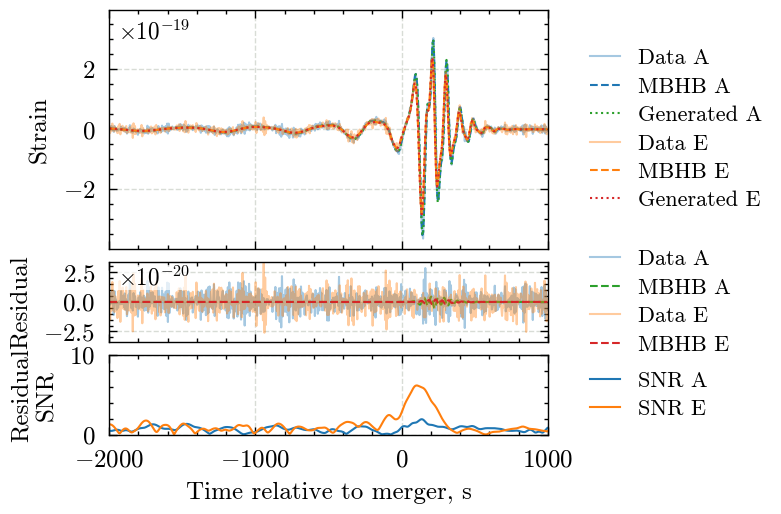

In [ ]:
# importlib.reload(plotting_utils)

fig = plotting_utils.plot_residual_snr(
    3,
    mbhb_sky[3],
    data,
    mbhb_data,
    data_residual,
    mbhb_residual,
    residual_data_snrs,
    generated,
    title=False,
)
# We might put this in the paper, maybe an appendix, dont save to the paper folder for now though
# fig.savefig('../../paper/images/figure_X_removal_residual.pdf')

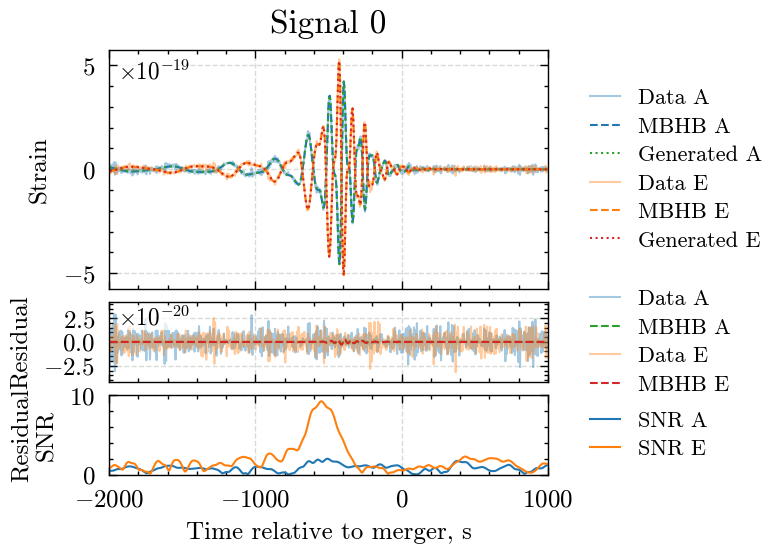

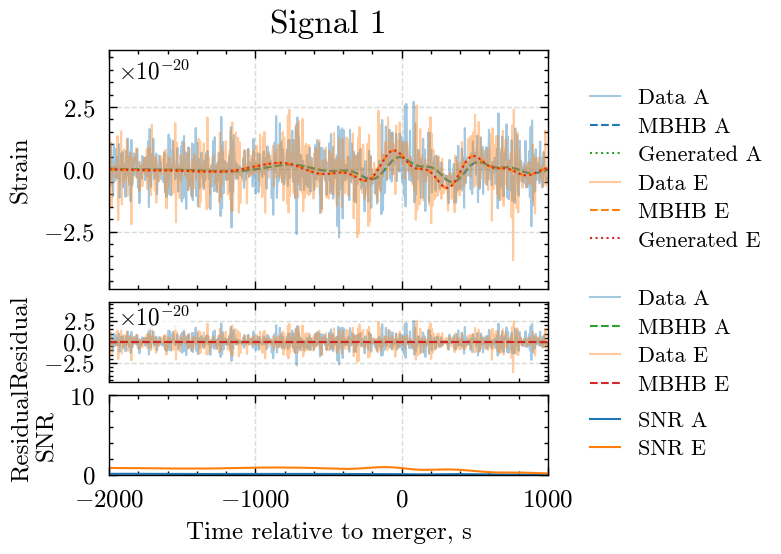

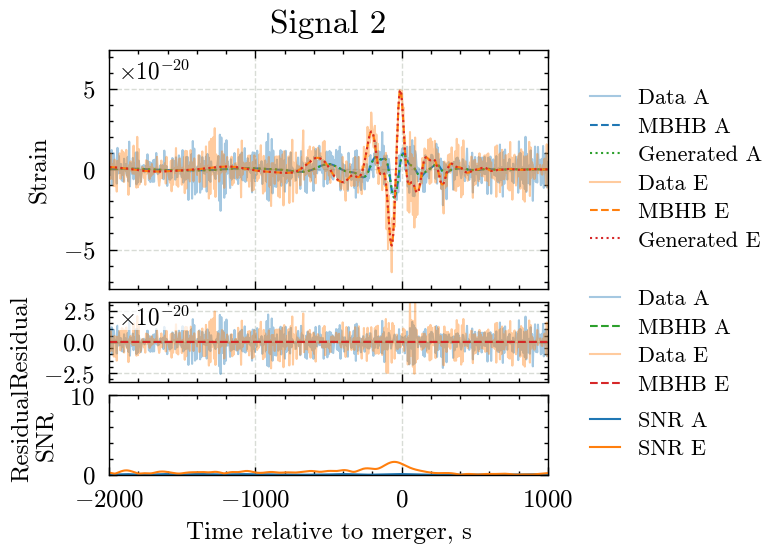

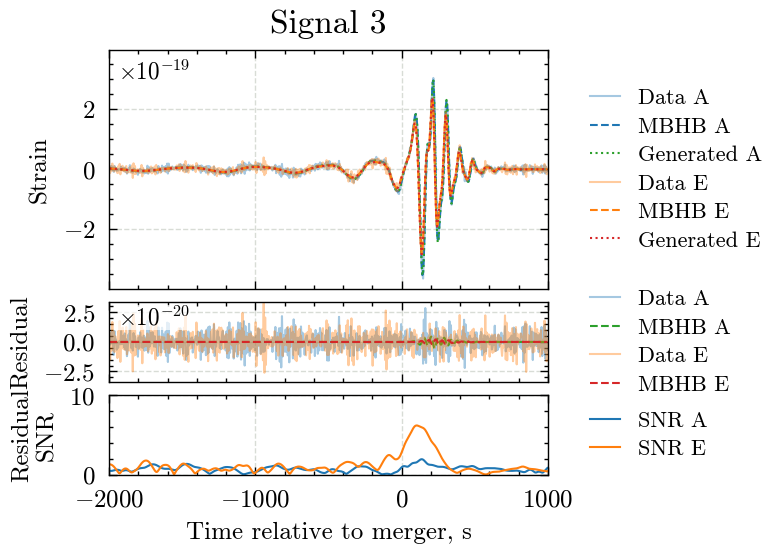

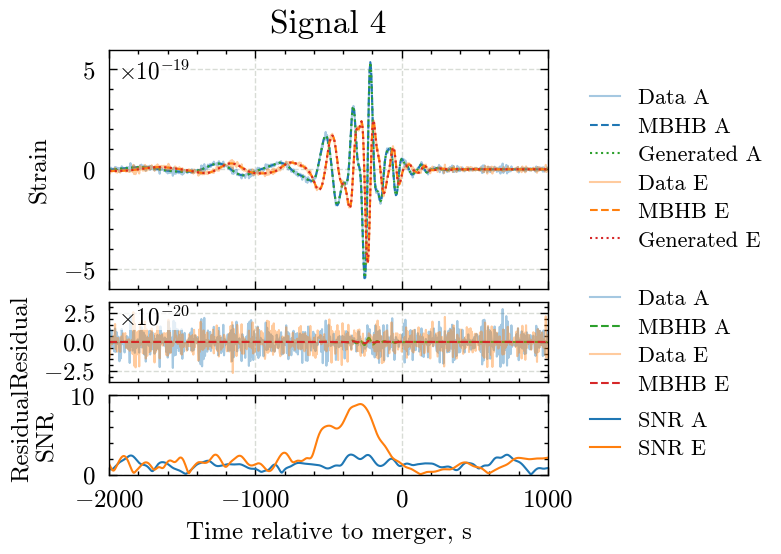

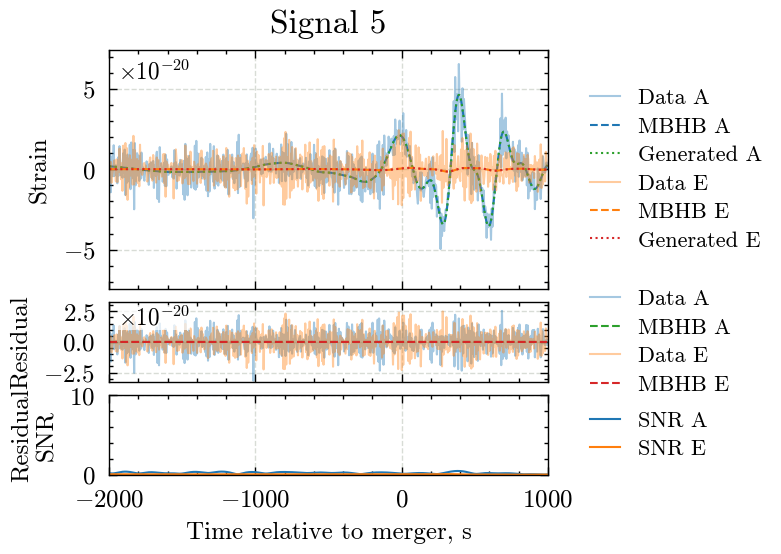

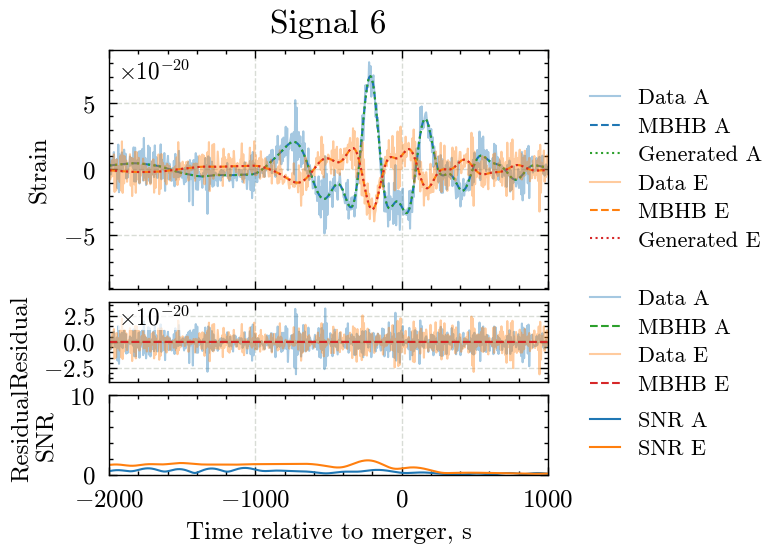

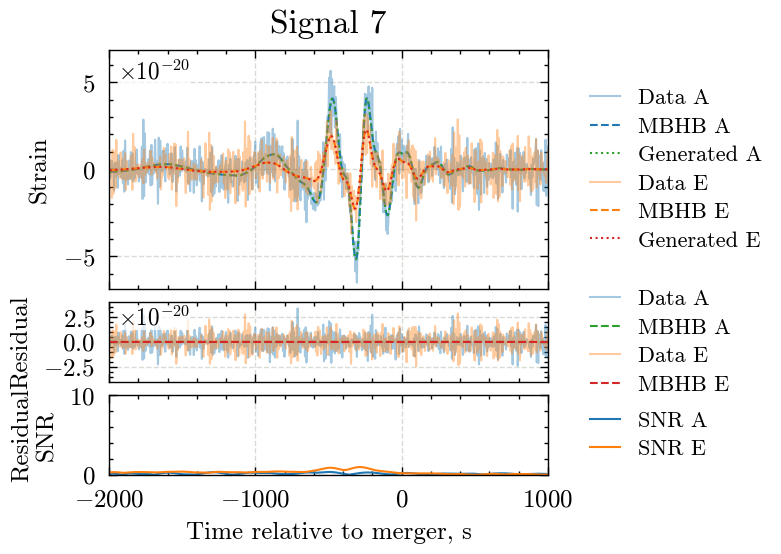

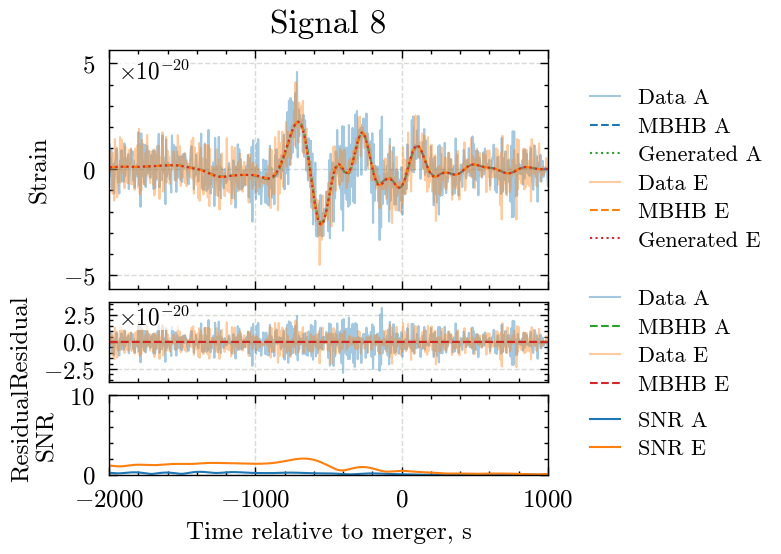

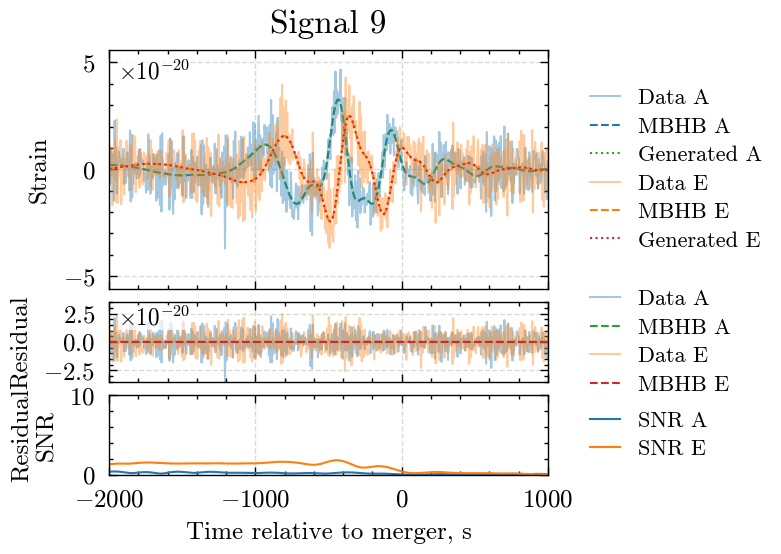

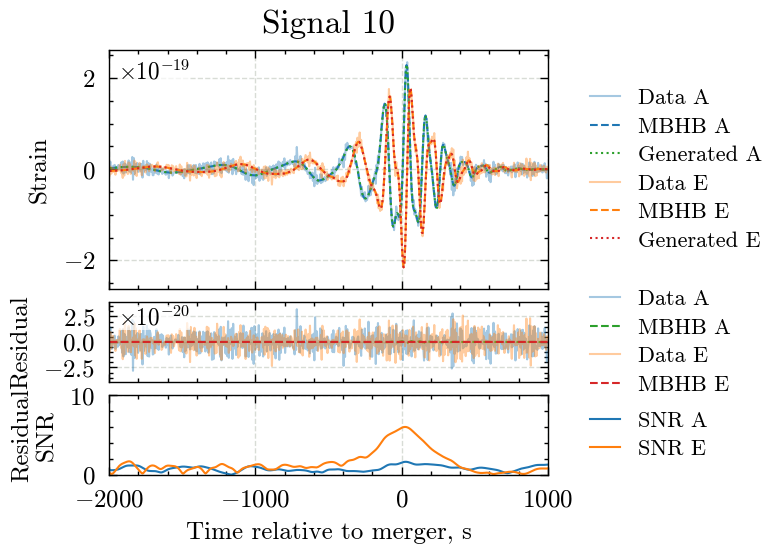

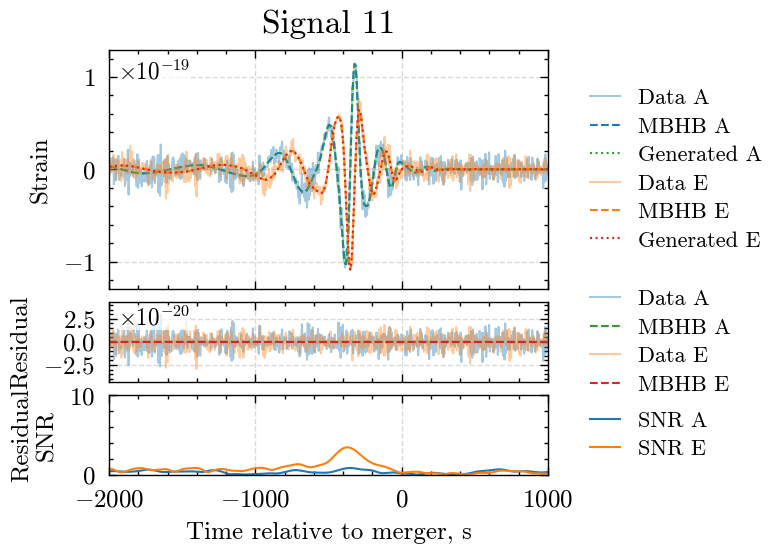

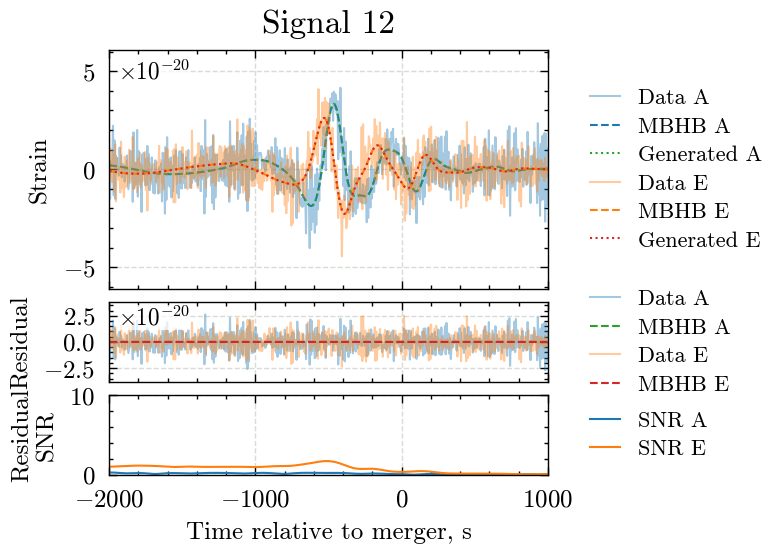

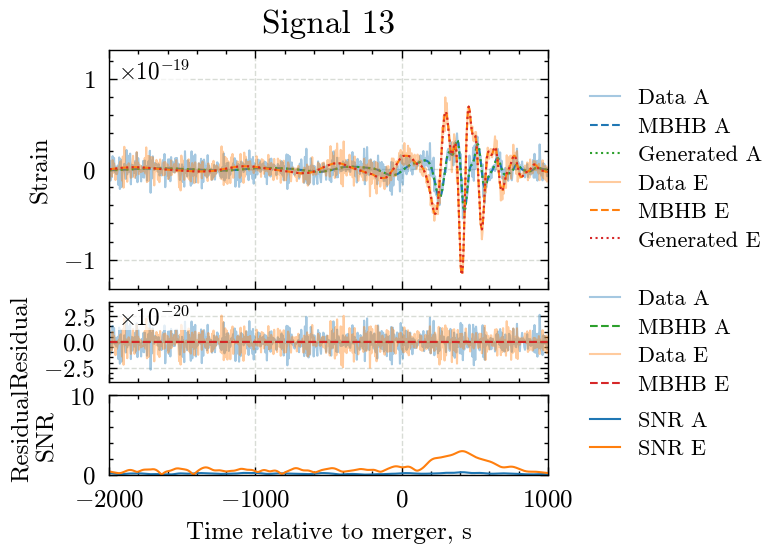

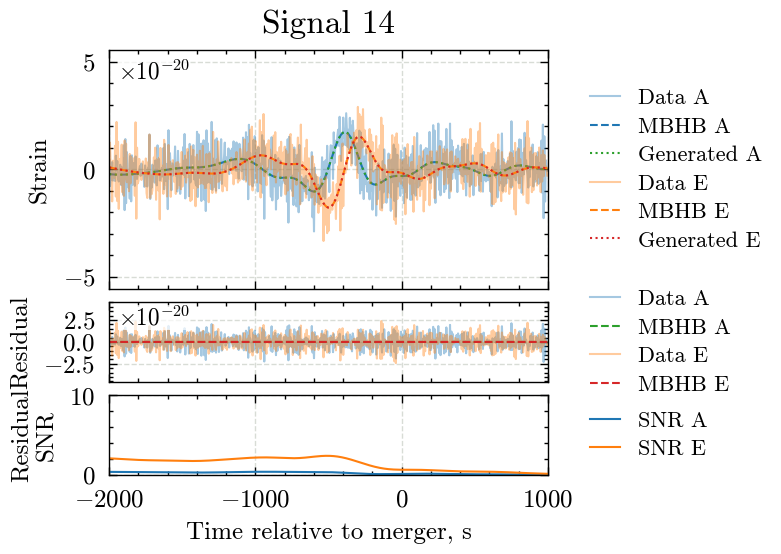

In [10]:
for signal_number, mbhb in enumerate(mbhb_sky):
    fig = plotting_utils.plot_residual_snr(
        signal_number,
        mbhb,
        data,
        mbhb_data,
        data_residual,
        mbhb_residual,
        residual_data_snrs,
        generated,
    )